<a href="https://colab.research.google.com/github/munhyunsik/ML/blob/ML/week5_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

학습 데이터(csv파일)

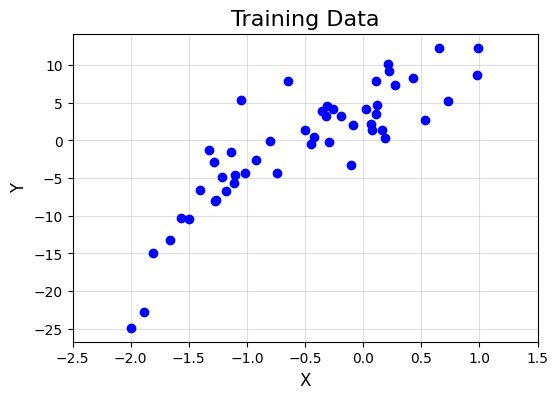

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#colab의 세션저장소에 업로드 기능을통해 직접 csv파일 업로드
x = pd.read_csv('/content/data0405.csv', usecols=['x']).values
y = pd.read_csv('/content/data0405.csv', usecols=['y']).values
plt.figure(figsize = (6, 4))
plt.plot(x, y, 'bo')
plt.title('Training Data', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.xlim(-2.5, 1.5)

plt.grid(alpha = 0.4)
plt.show()

# **최소제곱법 사용**

선형 예측모델의 파라미터 값, 예측 모델

In [50]:
A = np.hstack([x**0, x])
A = np.asmatrix(A)

w = (A.T*A).I*A.T*y
print('선형 예측 모델의 파라미터 값 w :\n', w)

선형 예측 모델의 파라미터 값 w :
 [[3.94188011]
 [8.73592461]]


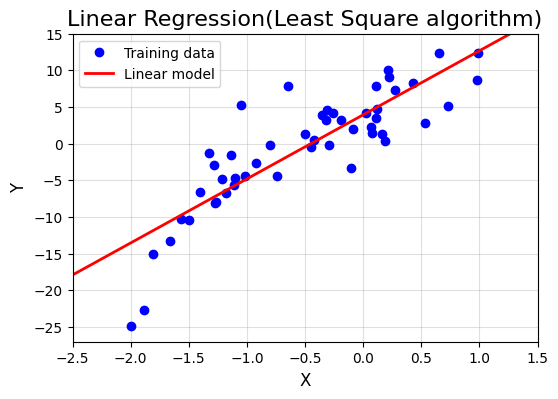

In [51]:
plt.figure(figsize = (6, 4))
plt.title('Linear Regression(Least Square algorithm)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

xp = np.arange(-3, 3, 0.01).reshape(-1, 1)
yp = w[0,0] + w[1,0]*xp
plt.plot(xp, yp, 'r', linewidth = 2, label = "Linear model")
plt.legend()
plt.xlim(-2.5, 1.5)
plt.ylim(-27, 15)

plt.grid(alpha = 0.4)
plt.show()

비선형(2차) 예측모델의 파라미터 값, 예측 모델

In [52]:
A = np.hstack([x**0, x, x**2])
A = np.asmatrix(A)

w = (A.T*A).I*A.T*y
print('비선형(2차)예측 모델의 파라미터값 w :\n', w)

비선형(2차)예측 모델의 파라미터값 w :
 [[ 5.03906362]
 [ 5.27924916]
 [-3.31676315]]


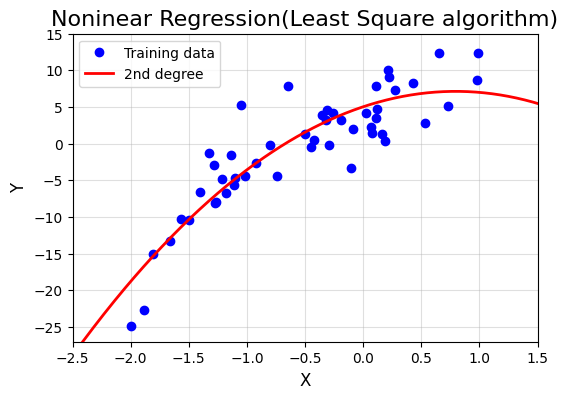

In [53]:
plt.figure(figsize = (6, 4))
plt.title('Noninear Regression(Least Square algorithm)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

xp = np.arange(-3, 3, 0.01).reshape(-1, 1)
yp = w[0,0] + w[1,0]*xp + w[2,0]*xp**2
plt.plot(xp, yp, 'r', linewidth = 2, label = "2nd degree")
plt.legend()
plt.xlim(-2.5, 1.5)
plt.ylim(-27, 15)

plt.grid(alpha = 0.4)
plt.show()

비선형(10차) 예측모델의 파라미터 값, 예측 모델

In [54]:
A = np.hstack([x**0, x, x**2, x**3, x**4, x**5, x**6, x**7, x**8, x**9, x**10])
#A = np.hstack([x**i for i in range(11)]) (반복문 사용)
A = np.asmatrix(A)

w = (A.T*A).I*A.T*y
print('비선형(10차)예측 모델의 파라미터값 w :\n', w)

비선형(10차)예측 모델의 파라미터값 w :
 [[  2.70561075]
 [  8.74663586]
 [ 24.11081429]
 [ -7.17740045]
 [-70.5948991 ]
 [-20.12073849]
 [ 59.53548303]
 [ 36.49128217]
 [ -8.88620238]
 [-11.06845299]
 [ -2.15841391]]


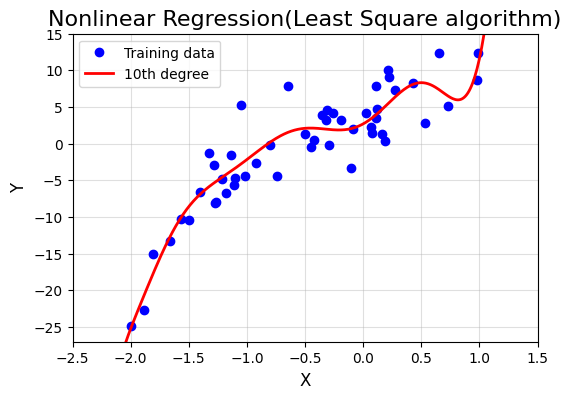

In [55]:
plt.figure(figsize = (6, 4))
plt.title('Nonlinear Regression(Least Square algorithm)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

xp = np.arange(-3, 3, 0.01).reshape(-1, 1)
yp = (
    w[0,0] + w[1,0]*xp + w[2,0]*xp**2 + w[3,0]*xp**3 +
    w[4,0]*xp**4 + w[5,0]*xp**5 + w[6,0]*xp**6 +
    w[7,0]*xp**7 + w[8,0]*xp**8 + w[9,0]*xp**9 + w[10,0]*xp**10
    )
plt.plot(xp, yp, 'r', linewidth = 2, label = "10th degree")
plt.legend()
plt.xlim(-2.5, 1.5)
plt.ylim(-27, 15)

plt.grid(alpha = 0.4)
plt.show()

# **경사하강법 사용**

선형 예측모델의 파라미터 값, 예측 모델

In [60]:
lrate = 0.001
epochs = 500
n = float(len(x))
w1 = 0
w0 = 0

for i in range(epochs):
    y_pred = w1*x + w0
    dw1 = (1/n) * sum(x * (y_pred-y))
    dw0 = (1/n) * sum(y_pred-y)
    w1 = w1 - lrate * dw1
    w0 = w0 - lrate * dw0
print ('선형 예측 모델의 파라미터 값\n w1 :',w1, '\n w0 :', w0)

선형 예측 모델의 파라미터 값
 w1 : [2.23603262] 
 w0 : [0.06825886]


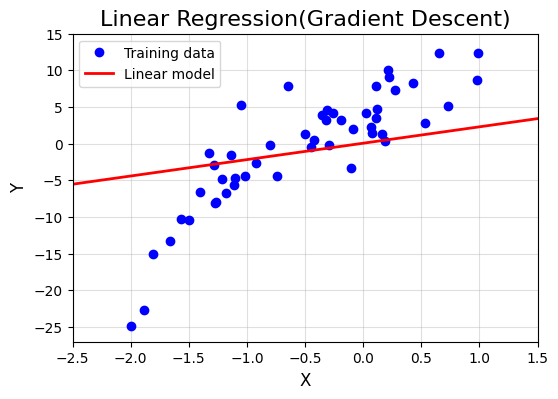

In [61]:
plt.figure(figsize = (6, 4))
plt.title('Linear Regression(Gradient Descent)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

xp = np.arange(-5, 5, 0.01).reshape(-1, 1)
y_pred = w1*xp + w0

plt.plot(xp, y_pred, 'r', linewidth = 2, label = "Linear model")
plt.legend()
plt.xlim(-2.5, 1.5)
plt.ylim(-27, 15)
plt.grid(alpha = 0.4)
plt.show()

비선형(2차) 예측모델의 파라미터 값,
예측 모델

In [76]:
lrate = 0.001
epochs = 500
n = float(len(x))
w2 = 0
w1 = 0
w0 = 0

for i in range(epochs):
    y_pred = w2*x**2 + w1*x + w0
    dw2 = (1/n) * sum((x**2) * (y_pred-y))
    dw1 = (1/n) * sum(x * (y_pred-y))
    dw0 = (1/n) * sum(y_pred-y)
    w2 = w2 - lrate * dw2
    w1 = w1 - lrate * dw1
    w0 = w0 - lrate * dw0
print ('비선형(2차) 예측 모델의 파라미터 값\n w2 :',w2, '\n w1 :', w1,
       '\n w0 :', w0 )

비선형(2차) 예측 모델의 파라미터 값
 w2 : [-2.02921761] 
 w1 : [1.71642697] 
 w0 : [0.46137619]


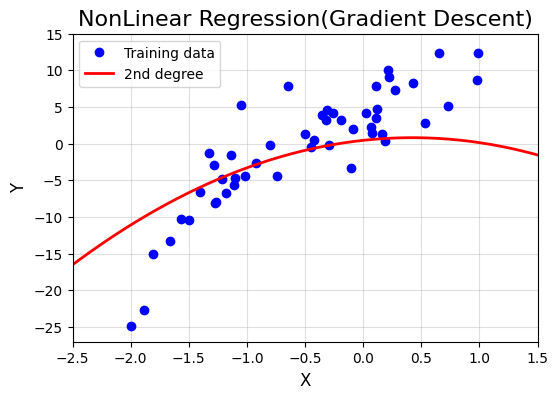

In [77]:
plt.figure(figsize = (6, 4))
plt.title('NonLinear Regression(Gradient Descent)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

xp = np.arange(-5, 5, 0.01).reshape(-1, 1)
y_pred = w2*xp**2 + w1*xp + w0

plt.plot(xp, y_pred, 'r', linewidth = 2, label = "2nd degree")
plt.legend()
plt.xlim(-2.5, 1.5)
plt.ylim(-27, 15)
plt.grid(alpha = 0.4)
plt.show()

비선형(4차) 예측모델의 파라미터 값, 예측 모델

In [88]:
lrate = 0.001
epochs = 500
n = float(len(x))
w4 = 0
w3 = 0
w2 = 0
w1 = 0
w0 = 0

for i in range(epochs):
    y_pred = w4*x**4 + w3*x**3 + w2*x**2 + w1*x + w0
    dw4 = (1/n) * sum((x**4) * (y_pred-y))
    dw3 = (1/n) * sum((x**3) * (y_pred-y))
    dw2 = (1/n) * sum((x**2) * (y_pred-y))
    dw1 = (1/n) * sum(x * (y_pred-y))
    dw0 = (1/n) * sum(y_pred-y)
    w4 = w4 - lrate * dw4
    w3 = w3 - lrate * dw3
    w2 = w2 - lrate * dw2
    w1 = w1 - lrate * dw1
    w0 = w0 - lrate * dw0
print ('비선형(4차) 예측 모델의 파라미터 값\n w4 :',w4, '\n w3 :', w3,
       '\n w2 :', w2, '\n w1 : ', w1, '\n w0 : ', w0 )

비선형(4차) 예측 모델의 파라미터 값
 w4 : [-1.04970844] 
 w3 : [0.9784752] 
 w2 : [-0.09587643] 
 w1 :  [0.61615766] 
 w0 :  [0.96730967]


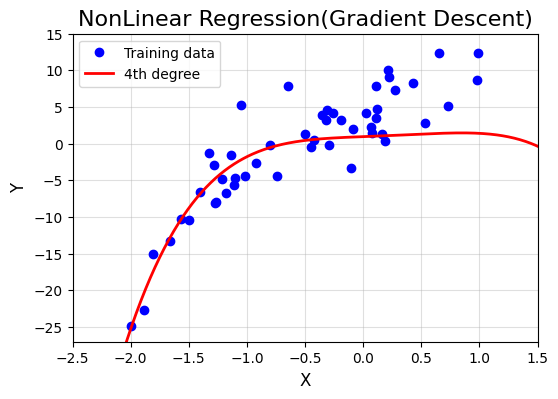

In [89]:
plt.figure(figsize = (6, 4))
plt.title('NonLinear Regression(Gradient Descent)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

xp = np.arange(-5, 5, 0.01).reshape(-1, 1)
y_pred = w4*xp**4 + w3*xp**3 + w2*xp**2 + w1*xp + w0

plt.plot(xp, y_pred, 'r', linewidth = 2, label = "4th degree")
plt.legend()
plt.xlim(-2.5, 1.5)
plt.ylim(-27, 15)
plt.grid(alpha = 0.4)
plt.show()

최소 제곱법과 경사하강법의 파라미터들을 살펴보면 선형예측모델 일때 보다 비선형 예측 모델일때(고차식) 학습데이터를 더욱 잘 따라가는것을 확인할수 있다. 또한 최소제곱법의 경우 동일한 차수의 예측모델이더라도 경사하강법을 사용한 예측모델보다 학습데이터를 잘 따라가는것을 확인할수 있는데 이를 통해 현재 경사하강법에 사용하고있는 학습률 0.001은 너무 작은값이라고 생각되며 이를 보완하기위해 학습률에 조금더 큰값을 저장하면 경사하강법 예측모델의 정확도가 오를것으로 예상된다.

In [86]:
#학습률 0.01 선택

lrate = 0.01
epochs = 500
n = float(len(x))
w4 = 0
w3 = 0
w2 = 0
w1 = 0
w0 = 0

for i in range(epochs):
    y_pred = w4*x**4 + w3*x**3 + w2*x**2 + w1*x + w0
    dw4 = (1/n) * sum((x**4) * (y_pred-y))
    dw3 = (1/n) * sum((x**3) * (y_pred-y))
    dw2 = (1/n) * sum((x**2) * (y_pred-y))
    dw1 = (1/n) * sum(x * (y_pred-y))
    dw0 = (1/n) * sum(y_pred-y)
    w4 = w4 - lrate * dw4
    w3 = w3 - lrate * dw3
    w2 = w2 - lrate * dw2
    w1 = w1 - lrate * dw1
    w0 = w0 - lrate * dw0
print ('비선형(4차) 예측 모델의 파라미터 값\n w4 :',w4, '\n w3 :', w3,
       '\n w2 :', w2, '\n w1 : ', w1, '\n w0 : ', w0 )

비선형(4차) 예측 모델의 파라미터 값
 w4 : [-0.36598114] 
 w3 : [2.38973336] 
 w2 : [0.55522403] 
 w1 :  [2.83675336] 
 w0 :  [3.55242938]


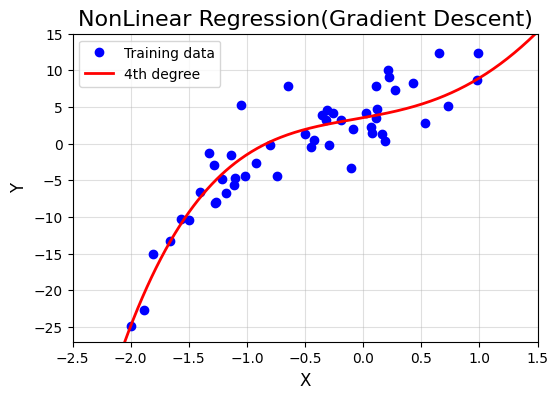

In [87]:
plt.figure(figsize = (6, 4))
plt.title('NonLinear Regression(Gradient Descent)', fontsize = 16)
plt.xlabel('X', fontsize = 12)
plt.ylabel('Y', fontsize = 12)
plt.plot(x, y, 'bo', label = "Training data")

xp = np.arange(-5, 5, 0.01).reshape(-1, 1)
y_pred = w4*xp**4 + w3*xp**3 + w2*xp**2 + w1*xp + w0

plt.plot(xp, y_pred, 'r', linewidth = 2, label = "4th degree")
plt.legend()
plt.xlim(-2.5, 1.5)
plt.ylim(-27, 15)
plt.grid(alpha = 0.4)
plt.show()